# CPS ASEC 2025 — Machine Learning: Wage Prediction

Predicting log annual wage from worker characteristics with five models: Linear, Ridge, Lasso, Random Forest, XGBoost.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
CLEANED_DATA_PATH = "../data/cps_cleaned.csv"


## Load data & restrict to full-time workers
Employed, positive wage, usual hours >= 35.

In [5]:
df = pd.read_csv(CLEANED_DATA_PATH)
print(f"Cleaned dataset: {len(df):,} rows")

df_ft = df[(df["EMPSTAT"].isin([10, 12])) & (df["INCWAGE"] > 0) & (df["UHRSWORKT"] >= 35)].copy()
print(f"Full-time workers: {len(df_ft):,}")


Cleaned dataset: 111,796 rows
Full-time workers: 52,883


## Features, target, train/test split
Target: log(INCWAGE). Survey weight ASECWT carried through for weighted model fitting.

In [6]:
numeric_features = ["AGE", "EDUC", "UHRSWORKT", "WKSWORK1"]
categorical_features = ["SEX", "MARST", "CLASSWKR", "OCC", "IND", "STATEFIP"]
features = numeric_features + categorical_features

X = df_ft[features]
y = np.log(df_ft["INCWAGE"])
weights = df_ft["ASECWT"].values

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")


Train: 42,306   Test: 10,577


## Preprocessing
Scale numeric features, one-hot encode categorical features.

In [7]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

feature_names = numeric_features + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
print(f"Feature matrix: {X_train_p.shape}, total features: {len(feature_names)}")


Feature matrix: (42306, 852), total features: 852


## Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train_p, y_train, sample_weight=w_train)
pred = lr.predict(X_test_p)

lr_rmse = np.sqrt(mean_squared_error(y_test, pred))
lr_mae = mean_absolute_error(y_test, pred)
lr_r2 = r2_score(y_test, pred)
print(f"Linear   RMSE={lr_rmse:.4f}  MAE={lr_mae:.4f}  R2={lr_r2:.4f}")


Linear   RMSE=0.6234  MAE=0.4249  R2=0.4512


## Ridge Regression

In [9]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_p, y_train, sample_weight=w_train)
pred = ridge.predict(X_test_p)

ridge_rmse = np.sqrt(mean_squared_error(y_test, pred))
ridge_r2 = r2_score(y_test, pred)
print(f"Ridge    RMSE={ridge_rmse:.4f}  R2={ridge_r2:.4f}")


Ridge    RMSE=0.6234  R2=0.4512


## Lasso Regression

In [10]:
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train_p, y_train, sample_weight=w_train)
pred = lasso.predict(X_test_p)

lasso_rmse = np.sqrt(mean_squared_error(y_test, pred))
lasso_r2 = r2_score(y_test, pred)
n_selected = int(np.sum(lasso.coef_ != 0))
print(f"Lasso    RMSE={lasso_rmse:.4f}  R2={lasso_r2:.4f}  (features used: {n_selected}/{len(feature_names)})")


Lasso    RMSE=0.6435  R2=0.4152  (features used: 101/852)


## Random Forest

In [11]:
rf = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_split=20, min_samples_leaf=10,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train_p, y_train, sample_weight=w_train)
pred = rf.predict(X_test_p)

rf_rmse = np.sqrt(mean_squared_error(y_test, pred))
rf_r2 = r2_score(y_test, pred)
print(f"RF       RMSE={rf_rmse:.4f}  R2={rf_r2:.4f}")

rf_importance = pd.DataFrame({"Feature": feature_names, "Importance": rf.feature_importances_}).sort_values("Importance", ascending=False).head(10)
rf_importance


RF       RMSE=0.6410  R2=0.4199


,Feature,Importance
1,EDUC,0.311128
3,WKSWORK1,0.294077
0,AGE,0.117350
2,UHRSWORKT,0.060020
6,MARST_1,0.029820
5,SEX_2,0.028269
4,SEX_1,0.025100
11,MARST_6,0.013201
746,IND_7860,0.010807
19,OCC_10,0.010115


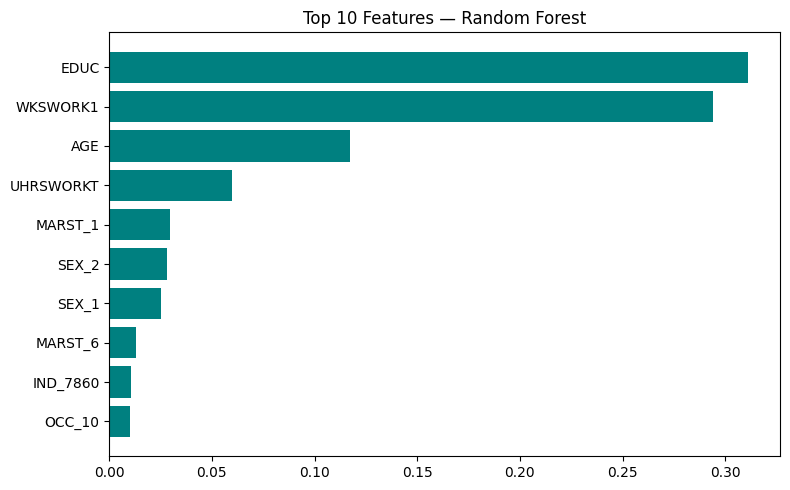

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
top = rf_importance.sort_values("Importance")
ax.barh(top["Feature"], top["Importance"], color="teal")
ax.set_title("Top 10 Features — Random Forest")
plt.tight_layout()
plt.show()


## XGBoost

In [13]:
xgb = XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=6, min_child_weight=3,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train_p, y_train, sample_weight=w_train)
pred = xgb.predict(X_test_p)

xgb_rmse = np.sqrt(mean_squared_error(y_test, pred))
xgb_r2 = r2_score(y_test, pred)
print(f"XGBoost  RMSE={xgb_rmse:.4f}  R2={xgb_r2:.4f}")

xgb_importance = pd.DataFrame({"Feature": feature_names, "Importance": xgb.feature_importances_}).sort_values("Importance", ascending=False).head(10)
xgb_importance


XGBoost  RMSE=0.6245  R2=0.4493


,Feature,Importance
3,WKSWORK1,0.019498
1,EDUC,0.017220
491,OCC_8620,0.015668
6,MARST_1,0.015099
775,IND_8680,0.013048
4,SEX_1,0.011784
21,OCC_40,0.010283
19,OCC_10,0.009923
81,OCC_1021,0.008493
731,IND_7380,0.008449


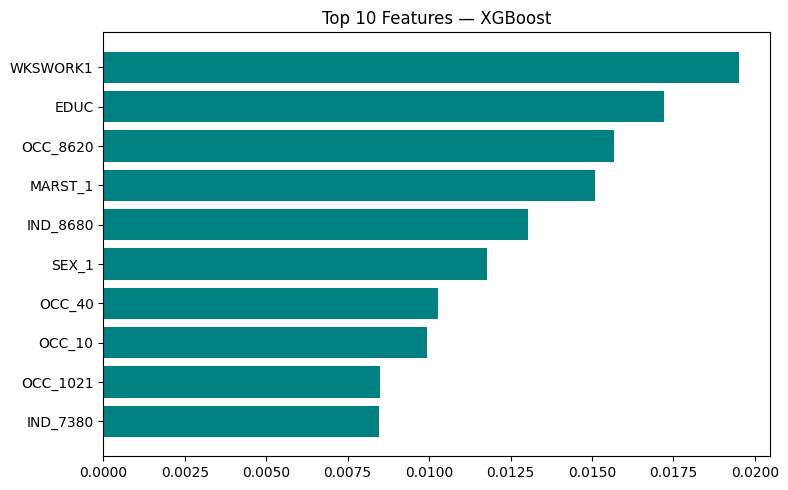

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
top = xgb_importance.sort_values("Importance")
ax.barh(top["Feature"], top["Importance"], color="teal")
ax.set_title("Top 10 Features — XGBoost")
plt.tight_layout()
plt.show()


## Model comparison

In [15]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, xgb_rmse],
    "R2": [lr_r2, ridge_r2, lasso_r2, rf_r2, xgb_r2],
}).sort_values("R2", ascending=False).reset_index(drop=True)
comparison


,Model,RMSE,R2
0,Ridge,0.623421,0.451173
1,Linear,0.623421,0.451171
2,XGBoost,0.624483,0.449300
3,Random Forest,0.640963,0.419850
4,Lasso,0.643547,0.415164


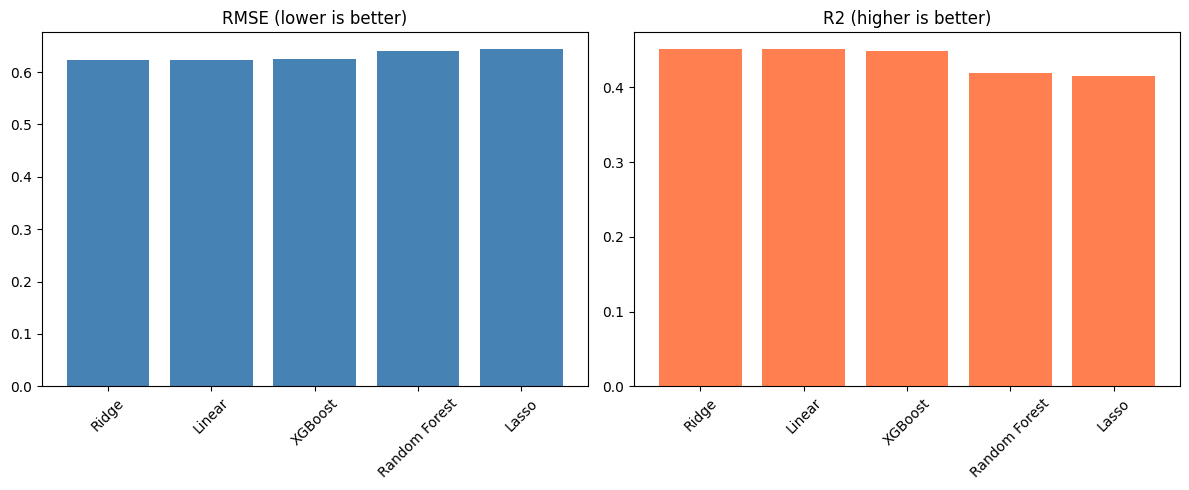

Best model: Ridge (R2=0.4512, RMSE=0.6234)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(comparison["Model"], comparison["RMSE"], color="steelblue")
axes[0].set_title("RMSE (lower is better)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(comparison["Model"], comparison["R2"], color="coral")
axes[1].set_title("R2 (higher is better)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

best = comparison.iloc[0]
print(f"Best model: {best['Model']} (R2={best['R2']:.4f}, RMSE={best['RMSE']:.4f})")
